# Gaussian Processes
***

In [1]:
def Train_gpr_model_5D(data, t):
    
    """Function to train gaussian process regression model (gpr) in 5D. 

    Inputs:
    ............................................................................
    data:   Dataframe. contains sintetic data simulated using vine copula model.
                       
    t:      Int. Group to train.  
    
    Outputs:
    ............................................................................
    gpr:    Trained gpr model"""
    
    # 1. Divide sample train and test 
    # ...........................................................................
    print('Training gaussian process regression model (5D)...')
    # Divide sample
    len_train = int(len(data)*0.9)
    train = Random_sample(data, len_train, random_state=0)
    test = data.drop(index=train.index)
    # Define train and test data
    # X values
    X_train = train[['parus','parvs', 'parws', 'parhs', 'pargs']].values
    X_test = test[['parus','parvs', 'parws', 'parhs', 'pargs']].values
    # Y values
    y_train = train[['cdf']].values
    y_test = test['cdf'].values
    
    # 2. Train gpr model
    # ...........................................................................
    kernel = 1.0 * RationalQuadratic(length_scale=3, alpha=1.5, alpha_bounds=(1e-2, 1))
    gpr = GaussianProcessRegressor(random_state=0, kernel = kernel).fit(X_train, y_train)
    print(gpr.score(X_train, y_train))
    
    # 2. Predict gpr values
    # ........................................................................... 
    y_pred = gpr.predict(X_test, return_std=False)
    
    # 3. Evaluate the performance of the model on the test data set
    #............................................................................
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("MSE:", mse)
    print("R2:", r2)
    
    # Absolute and relative error
    absoluto = np.around(abs((y_test-y_pred)),4)
    relativo = np.around(abs((y_test-y_pred)/y_test),4)
    
    # 3.1 Plot relative and absolute error data
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12,5), dpi = 90)
    ax1.plot(absoluto)
    ax1.set_ylabel('Error absoluto')
    ax1.set_title(str(t))
    ax2.plot(relativo)
    ax2.set_ylabel('Error relativo')
    
    fig.tight_layout();
    
    return gpr

In [2]:
def CDF_simulate_5D(θ, t):
    
    """Function to calculate cdf vine copula 5D using Montecarlo 
       integration and gpr model. 

    Inputs:
    ..............................................................
    θ:   Rpy2.robjects. Vine copula fitted model.
    t:   Int. Group to fit.  
    
    Outputs:
    ..............................................................
    simdf:  Dataframe. contains simulate data and cdf values"""
    
    # 1. Calculate cdf to train model (Using MonteCarlo integration)
    #........................................................................
    # Simulate and sample values
    sintetic = VineCopula.RVineSim(1_000_000, θ)
    sintetic = pd.DataFrame(sintetic, columns = ['parus', 'parvs', 'parws', 'parhs', 'pargs'])
    sample_5D = sintetic.sample(1_000)
    
    # Calculate cdf
    cdf5D = []
    for u, v, w, h, g in tqdm(zip(sample_5D.iloc[:,0], sample_5D.iloc[:,1], sample_5D.iloc[:,2], sample_5D.iloc[:,3], sample_5D.iloc[:,4])):
        cdf5D.append(vegas_mci_5D(θ, u, v, w, h, g))
    sample_5D['cdf'] = cdf5D
    sample_5D = sample_5D.sort_values('cdf')

    # 2. Train gpr model
    # ......................................................................
    gpr_5D = Train_gpr_model_5D(sample_5D, t)

    # 3. Interpolate model
    # ......................................................................
    # Split and predict CDF data (chunk)
    y_pred_append = np.array([]) # array to save cdf values
    lenght = int(len(sintetic)/25_000)
    for chunk in tqdm(np.array_split(sintetic.values, lenght)):
        y_pred = gpr_5D.predict(chunk, return_std=False)
        y_pred_append = np.append(y_pred_append, y_pred)
    sintetic['cdf'] = y_pred_append

    # 4. Recalculated interpol values less than zero
    # ................................................................................................................
    print('Recalculated interpolate values less than zero...')
    # Filter values less than zero
    recalculate = sintetic[sintetic['cdf']<0]
    # recalculated values
    for i in tqdm(recalculate.index):
        sintetic.loc[i,'cdf'] = 1e-5
        #sintetic.loc[i,'cdf'] = vegas_mci_5D(θ, recalculate.loc[i, 'parus'], recalculate.loc[i, 'parvs'], recalculate.loc[i, 'parws'], recalculate.loc[i, 'parhs'], recalculate.loc[i, 'pargs'])
    
    # sort values by cdf column
    sintetic = sintetic.sort_values('cdf')
    
    # This step beacuse interpolation model is an aprox. to improve tail behaviour cdf 
    print('Recalculated last 1000 values...')
    recalculate = sintetic.iloc[-1000:,[0,1,2,3,4,5]]  
    for i in tqdm(recalculate.index):
        sintetic.loc[i,'cdf'] = vegas_mci_5D(θ, recalculate.loc[i, 'parus'], recalculate.loc[i, 'parvs'], recalculate.loc[i, 'parws'], recalculate.loc[i, 'parhs'], recalculate.loc[i, 'pargs'])
    
    sintetic = sintetic.sort_values('cdf')
    
    # 5. Plot cdf
    # ................................................................................................................
    plt.figure()
    plt.plot(sintetic['cdf'].values)

    return sintetic

# Referencias
* https://scikit-learn.org/stable/modules/gaussian_process.html


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import pandas as pd
import xarray as xr
import rioxarray
from rasterio.enums import Resampling
import numpy as np
from cartopy import config
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import cartopy.mpl.ticker as cticker

from NEOPRENE.NSRP.HiperParams import Calibration as Calhps, Simulation as Simhps
from NEOPRENE.NSRP.Calibration import Calibration
from NEOPRENE.NSRP.Statistics import Statistics
from NEOPRENE.NSRP.Simulation import Simulation
from NEOPRENE.NSRP.Analysis import Analysis
import os

from pykrige.rk import Krige
from pykrige.uk import UniversalKriging
from pykrige.kriging_tools import read_asc_grid

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import joblib


import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import rasterio
import numpy.ma as ma
import math
import tqdm

import scipy.stats
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import *

from utils import *

# Análisis de datos de partida

In [5]:
# read elevation data of the rhine basin using rasterio
with rasterio.open("E:/ATLAS_PANAMA/02_GIS/mdt_1km.tif", "r") as src:
    elevtn = src.read(1).astype(float)
    nodata = src.nodata
    elevtn = ma.masked_array(elevtn, mask=elevtn==nodata)
    transform = src.transform
    crs = src.crs
    extent = np.array(src.bounds)[[0, 2, 1, 3]]
    latlon = src.crs.is_geographic
    prof = src.profile
    height = elevtn.shape[0]
    width  = elevtn.shape[1]
    cols, rows = np.meshgrid(np.arange(width), np.arange(height))
    xs, ys = rasterio.transform.xy(src.transform, rows, cols)
    lons= np.array(xs)
    lats = np.array(ys)

In [6]:
lon_min=-91
lon_max=-67
lat_min=3
lat_max=15

In [7]:
Location   = pd.read_csv('E:/ATLAS_PANAMA/02_GIS/Estaciones_UTM.csv',index_col=0)
Location_2 = pd.read_csv('E:/ATLAS_PANAMA/01_DATA/01_CLIMA/Datos_Instrumentales/Envio_16_05_2023/Estaciones_SEL.csv',index_col=0,encoding='latin-1')

In [8]:
Location

,ESTACIONES,PROVINCIA,TIPO_ESTAC,ELEVACIÓN,LONGITUD,LATITUD,Lon,Lat,Aspect,Slp,POINT_X,POINT_Y,Coast_Dist,Dist_River
CODIGO,,,,,,,,,,,,,,
91001,SIEYIK,BOCAS DEL TORO,AM,91,9º23'18'',82º39'04'',-82.651111,9.388333,27.646000,9.61115,318693.5594,1.038212e+06,21534.880750,285.075479
91026,CHANGUINOLA SUR,BOCAS DEL TORO,AM,400,8º57'38'',82º25'29'',-82.424722,8.960556,45.000000,9.74700,343370.7111,9.907947e+05,18453.695710,348.246403
93002,AEROPUERTO DE BOCAS,BOCAS DEL TORO,AM,2,9º20'25'',82º14'42'',-82.245000,9.340278,351.869995,2.86677,363277.1016,1.032714e+06,224.877485,15721.008470
97001,CALOVEBORA,VERAGUAS,AM,10,8º47'15'',81º12'36'',-81.210000,8.787500,14.036200,6.68639,476904.7007,9.713654e+05,85.561804,225.214250
102001,CERRO PUNTA,CHIRIQUI,CC,1830,8º52'00'',82º35'00'',-82.583333,8.866667,327.994995,7.64949,325885.0128,9.804822e+05,38532.425570,44.344109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148004,PIRIA (POBLADO),PANAMA,CM,80,9º07'26'',78º19'31'',-78.325278,9.123889,84.805603,4.47803,793990.7869,1.009638e+06,22005.436020,667.664782
148008,RIO MAJE,PANAMA,CC,70,9º01'00'',78º44'00'',-78.733333,9.016667,213.959000,23.95080,749189.1869,9.974676e+05,21477.106480,1695.913247
150002,CHIMAN,PANAMA,BC,30,8º43'01'',78º37'59'',-78.633056,8.716944,240.524002,32.13340,760430.5375,9.643742e+05,105.839034,984.998498


## Precipitación

In [9]:
Precipitation=pd.read_csv('E:/ATLAS_PANAMA/01_DATA/01_CLIMA/Datos_Instrumentales/Precipitation.csv',index_col=0, parse_dates=True,dtype=float)
Precipitation_2=pd.read_csv('E:/ATLAS_PANAMA/01_DATA/01_CLIMA/Datos_Instrumentales/Envio_16_05_2023/Precipitación/Precipitation_IHC.csv',index_col=0, parse_dates=True,dtype=float)

In [10]:
Precipitation_2 = Precipitation_2.loc[:,Location_2.index]

In [11]:
Pluvios   = Location.loc[Precipitation.columns.astype(int)]
Pluvios_2 = Location_2.copy()

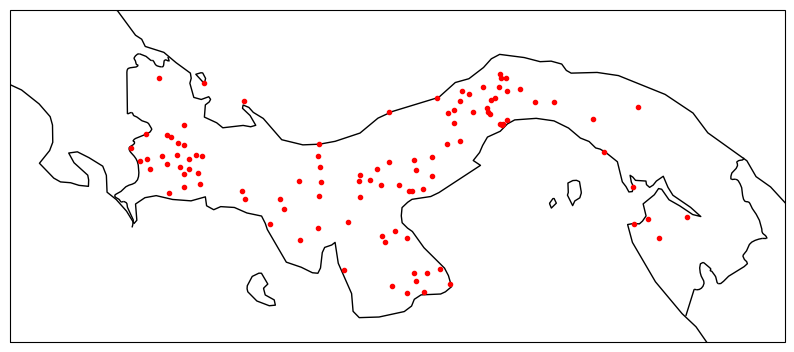

In [12]:
fig, ax = plt.subplots(1,1, figsize=(10,9),subplot_kw=dict(projection=ccrs.PlateCarree()))
cs=ax.plot(Pluvios.Lon,Pluvios.Lat,'.r')
ax.plot(Pluvios_2.Lon,Pluvios_2.Lat,'.r')
ax.set_extent([lon_min+7,lon_max-10,lat_min+4,lat_max-5])
ax.coastlines(resolution='50m')
ax.add_feature(cartopy.feature.BORDERS, linestyle='-')

In [13]:
Analisis_Prec=pd.DataFrame(index=Pluvios.index,columns=['Nª años completos','Porcentaje de huecos (%)','Nº años con dato',\
                                                        'Nº meses completos','Año inicio','Año fin'])
Analisis_Prec_2=pd.DataFrame(index=Pluvios_2.index,columns=['Nª años completos','Porcentaje de huecos (%)','Nº años con dato',\
                                                        'Nº meses completos','Año inicio','Año fin'])

In [14]:
for i in Pluvios.index:
    Analisis_Prec.loc[i]=analisis_calidad(Precipitation.loc[:,str(i)].astype(float), 1981, 1)

for i in Pluvios_2.index:
    Analisis_Prec_2.loc[i]=analisis_calidad(Precipitation_2.loc[:,str(i)].astype(float), 1981, 1)

In [15]:
Analisis_Prec.sort_values(by='Porcentaje de huecos (%)')

,Nª años completos,Porcentaje de huecos (%),Nº años con dato,Nº meses completos,Año inicio,Año fin
126012,39,0.040067,41,492,1981,2021
132010,36,0.046745,41,492,1981,2021
114002,37,0.166945,41,492,1981,2021
126002,39,0.247078,41,492,1981,2021
108015,35,0.260434,41,492,1981,2021
...,...,...,...,...,...,...
136002,25,21.856427,33,388,1981,2013
134004,18,30.15025,31,350,1981,2013
108042,6,66.392882,11,131,1990,2000
106012,None,None,None,None,None,None


In [16]:
Pluvios = Pluvios.loc[Analisis_Prec.dropna().index]
Pluvios_2 = Pluvios_2.loc[Analisis_Prec_2.dropna().index]

In [17]:
Precipitation = Precipitation.loc[:,Pluvios.index.astype(str)]
Precipitation_2 = Precipitation_2.loc[:,Pluvios_2.index.astype(str)]

In [18]:
Pluvios = pd.concat((Pluvios,Pluvios_2))
Pluvios.index = Pluvios.index.astype(str)

In [19]:
Precipitation = pd.concat((Precipitation,Precipitation_2),axis=1)

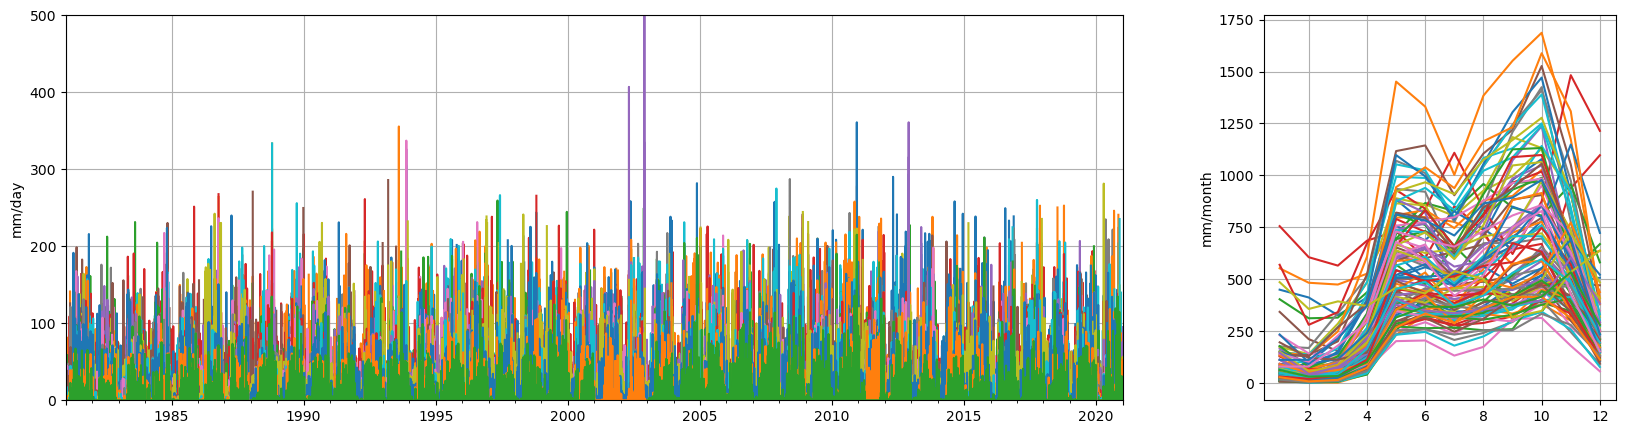

In [20]:
f, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [3, 1]}, figsize=(20, 5))

t1=str(Precipitation.index.year[0]); t2=str(Precipitation.index.year[-1])
Precipitation.plot(xlim=(t1, t2),  ylim=(0, 500), ax = ax0)
ax0.grid(True)
ax0.set_ylabel('mm/day')
ax0.get_legend().remove()

grouped_m = Precipitation.groupby(lambda x: x.month)
Month_sum=grouped_m.sum()*24/(len(Precipitation>=0)/30)
Month_sum.plot(ax = ax1)
ax1.grid(True)
ax1.set_ylabel('mm/month')
ax1.get_legend().remove()

### Análisis TRMM

In [21]:
TRMM_data = xr.open_dataset('E:/ATLAS_PANAMA/01_DATA/01_CLIMA/TRMM/Precipitacion_TRMM.nc')

In [22]:
TRMM_data = TRMM_data.where(TRMM_data['Precipitacion'] > 0)  

In [23]:
TRMM_data_day = TRMM_data.resample(time='D').sum()*3

In [24]:
TRMM_data_mean = TRMM_data_day.mean(dim='time')

In [25]:
TRMM_data_mean.to_netcdf('E:/ATLAS_PANAMA/01_DATA/01_CLIMA/TRMM/Precipitacion_TRMM_mean.nc')

In [26]:
Pluvios['TRMM_mean'] = np.nan

In [27]:
for i in Pluvios.index:
    Pluvios.loc[i,'TRMM_mean'] = TRMM_data_mean.Precipitacion.sel(lon=Pluvios.Lon.loc[i],lat=Pluvios.Lat.loc[i] ,method = 'nearest').data

In [28]:
Precipitation_TRMM = pd.DataFrame(index=TRMM_data_day.time.values, columns=Precipitation.columns)

In [30]:
for i in Precipitation.columns:
    Precipitation_TRMM.loc[:,i] = TRMM_data_day.Precipitacion.sel(lon=Pluvios.Lon.loc[i],lat=Pluvios.Lat.loc[i],method = 'nearest').data
    

In [31]:
Pluvios['Pmean'] = Precipitation.mean().values

In [32]:
Pluvios

,ESTACIONES,PROVINCIA,TIPO_ESTAC,ELEVACIÓN,LONGITUD,LATITUD,Lon,Lat,Aspect,Slp,POINT_X,POINT_Y,Coast_Dist,Dist_River,TRMM_mean,Pmean
91001,SIEYIK,BOCAS DEL TORO,AM,91.0,9º23'18'',82º39'04'',-82.651111,9.388333,27.646000,9.61115,318693.5594,1.038212e+06,21534.880750,285.075479,7.050824,8.558361
91026,CHANGUINOLA SUR,BOCAS DEL TORO,AM,400.0,8º57'38'',82º25'29'',-82.424722,8.960556,45.000000,9.74700,343370.7111,9.907947e+05,18453.695710,348.246403,7.664724,12.542173
93002,AEROPUERTO DE BOCAS,BOCAS DEL TORO,AM,2.0,9º20'25'',82º14'42'',-82.245000,9.340278,351.869995,2.86677,363277.1016,1.032714e+06,224.877485,15721.008470,9.034200,9.175203
97001,CALOVEBORA,VERAGUAS,AM,10.0,8º47'15'',81º12'36'',-81.210000,8.787500,14.036200,6.68639,476904.7007,9.713654e+05,85.561804,225.214250,8.175007,13.414347
102001,CERRO PUNTA,CHIRIQUI,CC,1830.0,8º52'00'',82º35'00'',-82.583333,8.866667,327.994995,7.64949,325885.0128,9.804822e+05,38532.425570,44.344109,8.258759,5.590295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Rio Piedras,Rio Piedras,PANAMA,ACP,198.0,-79.397773,9.283162,-79.397773,9.283162,321.773010,4.64630,675990.0000,1.026555e+06,NaN,NaN,7.543992,10.007591
RIO_CONGO,RIO_CONGO,DARIEN,ETESA,5.0,-78.369166,8.402778,-78.369166,8.402778,-9999.000000,-9999.00000,789722.2000,9.297985e+05,NaN,NaN,5.902179,7.084588
Salamanca,Salamanca,COLON,ACP,79.0,-79.583048,9.305655,-79.583048,9.305655,93.652199,7.06435,655625.0000,1.028956e+06,NaN,NaN,7.662799,12.259673
Santa Rosa,Santa Rosa,COLON,ACP,28.0,-79.654408,9.18599,-79.654408,9.185990,53.130100,0.12500,647836.0000,1.015692e+06,NaN,NaN,6.879894,4.970066


In [33]:
sel_pluvios = np.random.choice(np.arange(0,len(Pluvios)),len(Pluvios)-int(0.2*len(Pluvios)),replace=False)
cv_pluvios = Pluvios.iloc[list(set(np.arange(0,len(Pluvios)))-set(sel_pluvios))]
Pluvios_CV = Pluvios.iloc[sel_pluvios]

In [34]:
# Pluvios_CV.to_csv('Pluvios_Selected.csv')

In [35]:
# cv_pluvios.to_csv('E:/ATLAS_PANAMA/01_DATA/01_CLIMA/Datos_Instrumentales/Pluvios_CV.csv')

In [39]:
sel_pluvios = np.array([140005,118001,134019,148004,126005,128001,128010,108006,108013,108042,134020,112004,113001,136002]).astype(str)

In [40]:
cv_pluvios = Pluvios.loc[sel_pluvios]

In [41]:
Pluvios_CV = Pluvios.loc[list(set(Pluvios.index.values)-set(sel_pluvios))]

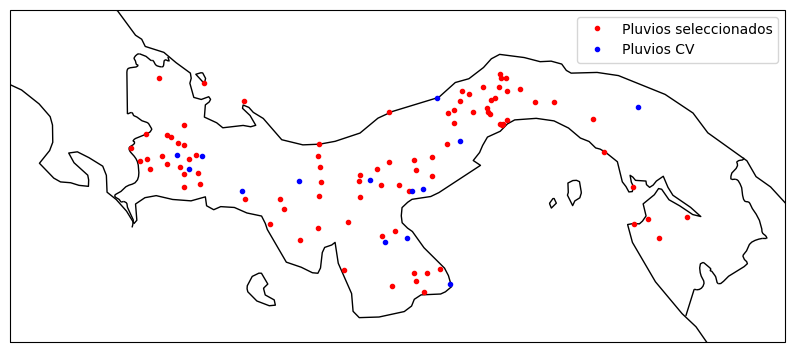

In [42]:
fig, ax = plt.subplots(1,1, figsize=(10,9),subplot_kw=dict(projection=ccrs.PlateCarree()))
cs=ax.plot(Pluvios_CV.Lon,Pluvios_CV.Lat,'.r',label = 'Pluvios seleccionados')
cs2=ax.plot(cv_pluvios.Lon,cv_pluvios.Lat,'.b',label = 'Pluvios CV')
ax.set_extent([lon_min+7,lon_max-10,lat_min+4,lat_max-5])
ax.coastlines(resolution='50m')
ax.add_feature(cartopy.feature.BORDERS, linestyle='-')
plt.legend()

In [43]:
Pluvios_CV.iloc[:,[3,10,11,14]]

,ELEVACIÓN,POINT_X,POINT_Y,TRMM_mean
108009,420.0,338595.6348,9.490956e+05,8.819274
118002,200.0,477029.1349,9.190665e+05,8.491850
BALBOA HEIGHTS,30.0,658982.0000,9.908170e+05,5.236740
114010,358.0,442479.0816,9.063842e+05,8.169247
BOCA_TRAMPA,100.0,815130.2000,8.784129e+05,8.741343
...,...,...,...,...
DIABLO H,5.0,656859.0000,9.913490e+05,5.236740
ESCANDALOSA,480.0,656121.0000,1.042137e+06,7.662799
148008,70.0,749189.1869,9.974676e+05,6.244840
Gatun,30.5,618528.0000,1.024753e+06,7.572241


In [44]:
# Define train and test data
# X values
X_train = Pluvios_CV.iloc[:,[3,10,11,14]].values
X_test = cv_pluvios.iloc[:,[3,10,11,14]].values
# Y values
y_train = Pluvios_CV.iloc[:,-1].values
y_test  = cv_pluvios.iloc[:,-1].values

min_max_scaler = preprocessing.MinMaxScaler()
X_train_scaled = min_max_scaler.fit_transform(X_train)
X_test_scaled = min_max_scaler.transform(X_test)

In [45]:
# 2. Train gpr model
# ...........................................................................
kernel = 1.0 * RationalQuadratic(length_scale=3, alpha=1.5, alpha_bounds=(-1, 1))
#kernel = 1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-1, 10.0))
kernel = 1*ConstantKernel(0.1, (0.01, 10.0)) * (
     DotProduct(sigma_0=1.0, sigma_0_bounds=(0.1, 10.0))** 2)*(
     Exponentiation(RationalQuadratic(),exponent=2))

#kernel = 1*Exponentiation(RationalQuadratic(length_scale=3, alpha=1.5, alpha_bounds=(-1, 1)), exponent=2)

# kernel = 1.0*ConstantKernel(0.1, (0.01, 10.0)) * (
#      DotProduct(sigma_0=1.0, sigma_0_bounds=(0.1, 10.0)) ** 2 *
#      RationalQuadratic(length_scale=3, alpha=1.5, alpha_bounds=(-1, 1)))
# )
# kernel = 1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-1, 10.0), nu=1.5)* (
#      DotProduct(sigma_0=1.0, sigma_0_bounds=(0.1, 10.0)) ** 2)

# kernel = 59.3**2 * RBF(length_scale=390) + 2.33**2 * RBF(length_scale=2.33e+03) * \
# ExpSineSquared(length_scale=1.26, periodicity=1.09) + 0.596**2 * \
# RationalQuadratic(alpha=1.5, length_scale=4.74) + 0.183**2 * \
# RBF(length_scale=0.133) + WhiteKernel(noise_level=0.0111)

gpr = GaussianProcessRegressor(random_state=0, kernel = kernel).fit(X_train_scaled, y_train)
print(gpr.score(X_train_scaled, y_train))

# 2. Predict gpr values
# ........................................................................... 
y_pred = gpr.predict(X_test_scaled, return_std=False)

1.0


MSE: 4.194889168489742
R2: 0.6431944789121371


Text(0, 0.5, 'Error relativo')

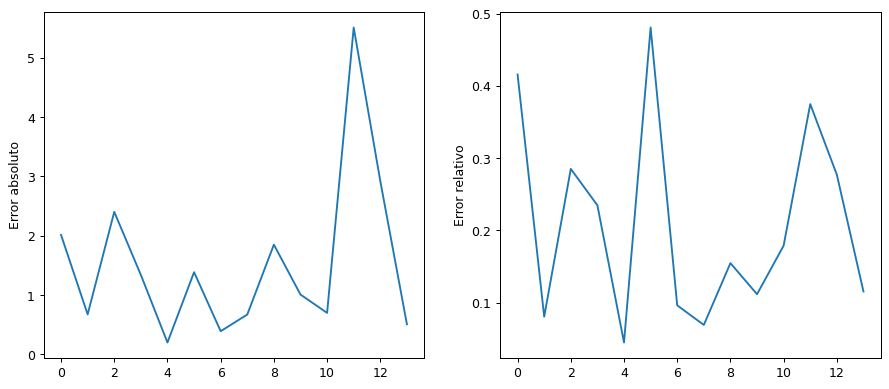

In [46]:
# 3. Evaluate the performance of the model on the test data set
#............................................................................
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2:", r2)

# Absolute and relative error
absoluto = np.around(abs((y_test-y_pred)),4)
relativo = np.around(abs((y_test-y_pred)/y_test),4)

# 3.1 Plot relative and absolute error data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12,5), dpi = 90)
ax1.plot(absoluto)
ax1.set_ylabel('Error absoluto')
ax2.plot(relativo)
ax2.set_ylabel('Error relativo')

In [47]:
mdt_asc     = read_asc_grid('E:/ATLAS_PANAMA/02_GIS/mdt_1km.asc')
near_c_asc  = read_asc_grid('E:/ATLAS_PANAMA/02_GIS/near_coast_1km.asc')
lon_ras_asc = read_asc_grid('E:/ATLAS_PANAMA/02_GIS/lon_ras.asc')
lat_ras_asc = read_asc_grid('E:/ATLAS_PANAMA/02_GIS/lat_ras.asc')
TRMM_asc    = read_asc_grid('E:/ATLAS_PANAMA/02_GIS/TRMM_ras_1km.asc')

In [48]:
[XX,YY] = np.meshgrid(mdt_asc[1] ,mdt_asc[2])

In [49]:
mdt_vec    = mdt_asc[0].flatten()
TRMM_vec   = TRMM_asc[0].flatten()
near_c_vec = near_c_asc[0].flatten()

TRMM_vec   = TRMM_vec[mdt_vec!=-9999]
near_c_vec = near_c_vec[mdt_vec!=-9999]

xx   = XX.flatten()
yy   = YY.flatten()

xx = xx[mdt_vec!=-9999]
yy = yy[mdt_vec!=-9999]
mdt_vec = mdt_vec[mdt_vec!=-9999]

X_test_malla        = np.vstack((mdt_vec,xx,yy,TRMM_vec)).T
X_test_malla_scaled = min_max_scaler.transform(X_test_malla)

In [50]:
y_pred = gpr.predict(X_test_malla_scaled, return_std=False)

In [51]:
result = mdt_asc[0].flatten()
result[result!=-9999] = y_pred*365
result = result.reshape(mdt_asc[0].shape)
result[result<0] = -9999
result = np.flipud(result)

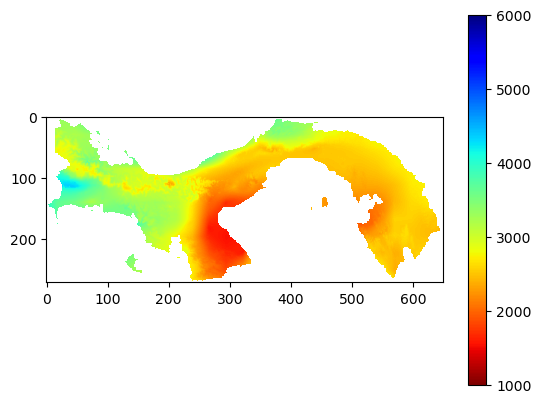

In [52]:
result[result<0] = np.nan
plt.imshow(result,cmap='jet_r',vmin=1000,vmax=6000)
plt.colorbar()

__Evaluamos la reconstrucción temporal___

In [55]:
kernel = gpr.kernel_

In [57]:
Precipitacion_rell    = pd.read_csv('E:/ATLAS_PANAMA/01_DATA/01_CLIMA/Reconstruccion/Precipitation_Rell_2.csv',index_col=0, parse_dates=True)
Precipitacion_rell[Precipitacion_rell<=0] = 0.0000001
Precipitacion_rell    = Precipitacion_rell.loc['1981':,:]
Precipitacion_rell_CV = Precipitacion_rell.loc[:,Pluvios_CV.index]
Prec_rec_cv           = pd.DataFrame(index=Precipitacion_rell_CV.index,columns=cv_pluvios.index)

In [58]:
for d in tqdm.tqdm(range(0,len(Precipitacion_rell))):
    X_train = min_max_scaler.transform(Pluvios_CV.iloc[:,[3,10,11,14]].values)
    y_train = Precipitacion_rell_CV.iloc[d].values
    
    gpr = GaussianProcessRegressor(random_state=0, kernel = kernel).fit(X_train, y_train)
    y_pred = gpr.predict(X_test_scaled, return_std=False)
    
    Prec_rec_cv.iloc[d,:] = y_pred
    
Prec_rec_cv[Prec_rec_cv<0.01]=0

100%|████████████████████████████████████████████████████████████████████████████| 15341/15341 [17:22<00:00, 14.71it/s]


In [59]:
resultados_CV = pd.DataFrame(index=cv_pluvios.index.astype(str), columns=['Corr','Bias','RMSE','R2'])

In [60]:
import hydroeval as he
    
def rsquared(x, y):
    """ Return R^2 where x and y are array-like."""

    slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x, y)
    return r_value**2

In [61]:
for p in cv_pluvios.index.astype(str):
    real = Precipitation.loc[:,p]
    sim  = Prec_rec_cv.loc[:,p]
    concat = pd.concat((real,sim),axis=1)
    
    x_ = concat.dropna().iloc[:,0].values.astype(float)
    y_ = concat.dropna().iloc[:,1].values.astype(float)
    
    bias  = he.pbias(y_,x_)
    r2    = rsquared(x_, y_)
    corr  = scipy.stats.pearsonr(x_,y_)[0]
    rmse  = np.sqrt(np.mean((y_-x_)**2))
    
    resultados_CV.loc[p,:] = [corr,bias,rmse,r2]

In [62]:
resultados_CV

,Corr,Bias,RMSE,R2
140005,-0.03589,92.835809,13.143964,0.001288
118001,-0.08695,96.161278,19.612313,0.00756
134019,-0.094989,96.824775,19.509772,0.009023
148004,-0.020513,94.186579,15.125791,0.000421
126005,0.042553,95.969868,13.516442,0.001811
128001,-0.012585,94.377063,9.693106,0.000158
128010,0.002022,96.230262,12.225848,0.000004
108006,-0.090803,96.037807,20.683591,0.008245
108013,-0.066211,97.257677,27.101545,0.004384
108042,-0.078412,95.974939,23.010907,0.006148


<AxesSubplot: >

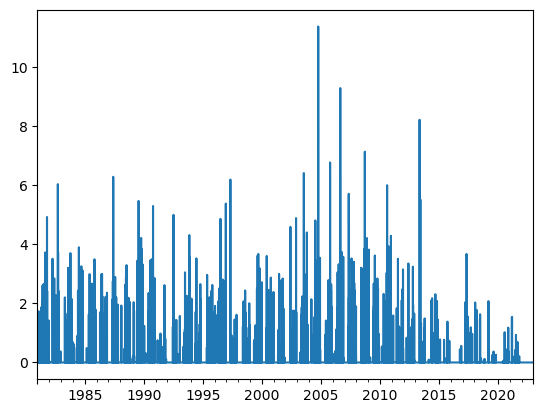

In [322]:
Prec_rec_cv.iloc[:,0].plot()

In [323]:
concat.columns = ['Real','Sim']

<AxesSubplot: >

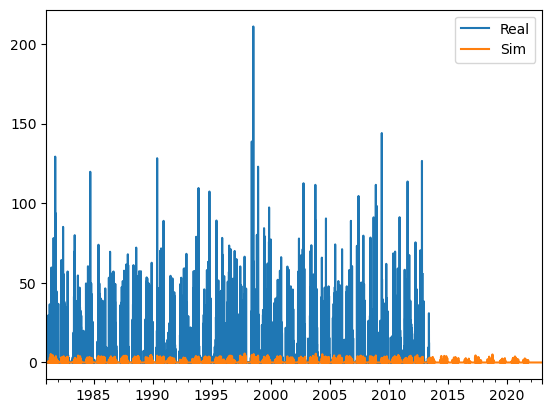

In [324]:
concat.plot()